In [126]:
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
df=pd.read_csv('customer_churn_data.csv')

In [128]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [130]:
df.isna()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,True,False,False,False
997,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,True,False,False,False


In [131]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [132]:
df["InternetService"]

0      Fiber Optic
1      Fiber Optic
2      Fiber Optic
3              DSL
4              NaN
          ...     
995    Fiber Optic
996            NaN
997    Fiber Optic
998            NaN
999            NaN
Name: InternetService, Length: 1000, dtype: object

In [133]:
df["InternetService"]=df["InternetService"].fillna("")

In [134]:
df['InternetService'].isna().sum()

0

In [135]:
df.duplicated().sum()

0

In [136]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [137]:
numeric_columns_data=df.select_dtypes(include=['number'])

In [138]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


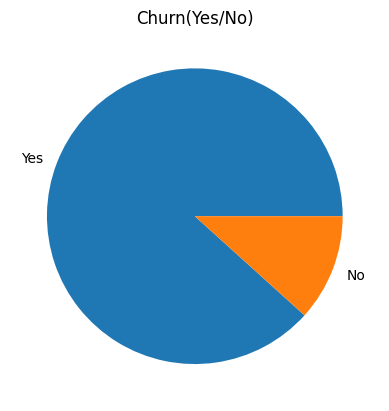

In [139]:
df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn(Yes/No)")
plt.ylabel("")
plt.show()

In [140]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [141]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [142]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [143]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

Text(0.5, 0, 'Contract Type')

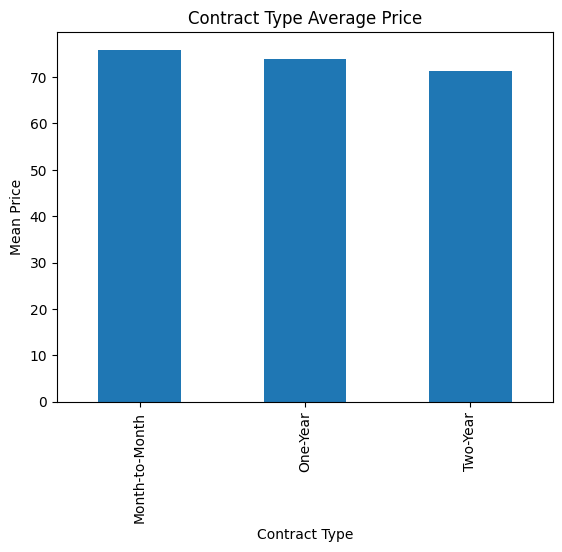

In [144]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Contract Type Average Price")
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")


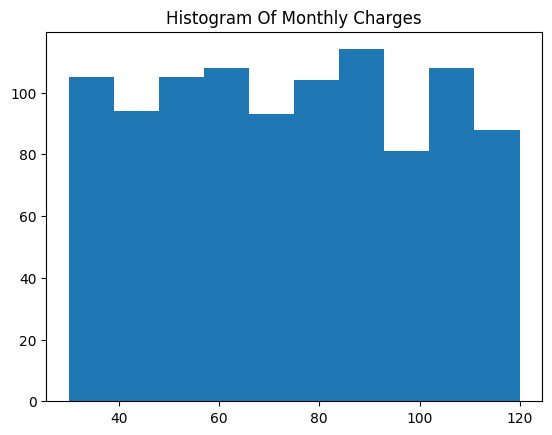

In [145]:
plt.hist(df["MonthlyCharges"])
plt.title("Histogram Of Monthly Charges")
plt.show()

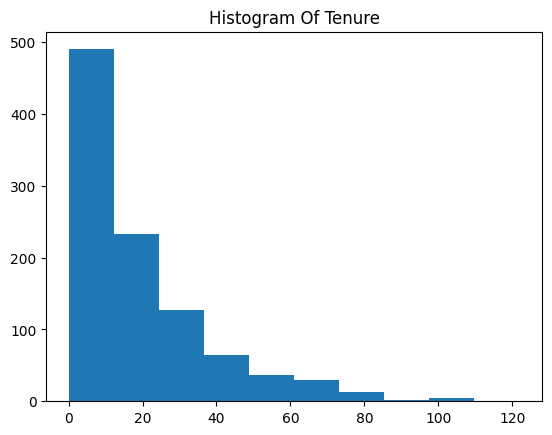

In [146]:
plt.hist(df["Tenure"])
plt.title("Histogram Of Tenure")
plt.show()

In [147]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [148]:
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [149]:
y=df["Churn"]
X=df[["Age","Gender","Tenure","MonthlyCharges"]]

In [150]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [151]:
y

0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
995    Yes
996    Yes
997    Yes
998    Yes
999    Yes
Name: Churn, Length: 1000, dtype: object

In [152]:
#0 Female 1 Male
X["Gender"]

0        Male
1        Male
2      Female
3      Female
4        Male
        ...  
995      Male
996      Male
997    Female
998      Male
999      Male
Name: Gender, Length: 1000, dtype: object

In [153]:
X["Gender"]=X["Gender"].apply(lambda x: 1 if x=="Male" else 0 )

In [154]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,1,4,88.35
1,43,1,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,1,32,69.01
...,...,...,...,...
995,42,1,41,37.14
996,62,1,9,80.93
997,51,0,15,111.72
998,39,1,68,65.67


In [155]:
type(X["Gender"][0])

numpy.int64

In [156]:
y.head(1)

0    Yes
Name: Churn, dtype: object

In [157]:
y=y.apply(lambda x:1 if x=="Yes" else 0)

In [158]:
type(y[0])

numpy.int64

In [159]:
y

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Churn, Length: 1000, dtype: int64

In [160]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [161]:
from sklearn.preprocessing import StandardScaler

In [162]:
scaler=StandardScaler()

In [163]:
X_train=scaler.fit_transform(X_train)


In [164]:
import joblib
joblib.dump(scaler,'scaler.pkl')


['scaler.pkl']

In [165]:
X_test=scaler.transform(X_test)

In [166]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 4)
(200, 4)
(800,)
(200,)


In [182]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy Score On Model is: {}".format(accuracy_score(y_test,predictions)))

In [168]:
from sklearn.linear_model import LogisticRegression


In [169]:
log_model=LogisticRegression()

In [170]:
import  warnings
warnings.filterwarnings("ignore")


In [171]:
log_model.fit(X_train,y_train)

LogisticRegression()

In [172]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,1,4,88.35
1,43,1,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,1,32,69.01
...,...,...,...,...
995,42,1,41,37.14
996,62,1,9,80.93
997,51,0,15,111.72
998,39,1,68,65.67


In [179]:
y_pred=log_model.predict(X_test)

In [180]:
y_test

702    1
501    1
724    1
240    1
869    0
      ..
773    1
912    1
349    1
922    1
261    1
Name: Churn, Length: 200, dtype: int64

In [183]:
modelperformance(y_pred)

Accuracy Score On Model is: 0.865


In [184]:
from sklearn.neighbors import KNeighborsClassifier


In [185]:
param_grid={
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"],
}

In [187]:
from sklearn.model_selection import GridSearchCV
gridkn=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)


In [188]:
gridkn.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [189]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [190]:
y_pred=gridkn.predict(X_test)

In [191]:
modelperformance(y_pred)

Accuracy Score On Model is: 0.85


In [192]:
from sklearn.svm import SVC

In [193]:
svm=SVC()

In [194]:
param_grid={
    "C":[0.01,0.1,0.5,1],
    "kernel":["linear","rbf","polynomial"],

}

In [195]:
gridscv=GridSearchCV(svm,param_grid,cv=5)

In [196]:
gridscv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'polynomial']})

In [197]:
gridscv.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [198]:
y_pred=gridscv.predict(X_test)

In [199]:
modelperformance(y_pred)

Accuracy Score On Model is: 0.86


In [200]:
from sklearn.tree import DecisionTreeClassifier

In [201]:
param_grid={
    "criterion":["gini","entropy"],
    "splitter":["best","random"],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [202]:
grid_tree=GridSearchCV(DecisionTreeClassifier(),param_grid,cv=5)

In [203]:
grid_tree.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [204]:
y_pred=grid_tree.predict(X_test)

In [205]:
modelperformance(y_pred)

Accuracy Score On Model is: 0.82


In [206]:
from sklearn.ensemble import RandomForestClassifier

In [207]:
rfc=RandomForestClassifier()

In [211]:
param_grid={
    "n_estimators":[32,64,128,256],
    "max_features":[2,3,4],
    "bootstrap":[True,False]
}

In [212]:
grid_rfc=GridSearchCV(rfc,param_grid,cv=5)

In [213]:
grid_rfc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [214]:
y_pred=grid_rfc.predict(X_test)

In [215]:
modelperformance(y_pred)

Accuracy Score On Model is: 0.85


In [216]:
best_model=log_model

In [218]:
joblib.dump(best_model,'churn_model.pkl')

['churn_model.pkl']